# Issue #1398: single-flat preprocessing check

Load one raw flat exposure, remove its detector overscan with the pipeline image-assembly module, subtract the pipeline-selected master bias, and inspect the first 500 detector rows across all columns. Order tracing intentionally stops after this visual check.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

from kpfpipe import REPO_ROOT
from kpfpipe.data_models.level0 import KPF0
from kpfpipe.modules.calibration_association import CalibrationAssociation
from kpfpipe.modules.image_assembly import ImageAssembly
from kpfpipe.modules.image_processing import ImageProcessing

# Git-backed receipt provenance requires the kernel to have a valid working
# directory. This also recovers kernels launched from a directory later removed.
os.chdir(REPO_ROOT)

data_root = Path.home() / "data" / "kpf"
obs_id = "KP.20240923.00139.44"
l0_path = data_root / "L0" / "20240923" / f"{obs_id}.fits"

if not l0_path.is_file():
    raise FileNotFoundError(l0_path)

l0_path

PosixPath('/Users/howardisaacson/data/kpf/L0/20240923/KP.20240923.00139.44.fits')

In [2]:
# ImageAssembly converts amplifier data to electrons, estimates read noise,
# subtracts the row-median overscan, removes the overscan pixels, and stitches
# the active regions into GREEN_CCD and RED_CCD full-frame images.
l0 = KPF0.from_fits(str(l0_path))
l1 = ImageAssembly(
    l0,
    config={"overscan_method": "rowmedian", "readnoise_sigma": 10.0},
).perform()

{chip: l1.data[f"{chip}_CCD"].shape for chip in ("GREEN", "RED")}

{'GREEN': (4080, 4080), 'RED': (4080, 4080)}

In [3]:
# Use the pipeline association logic to select the nearest master bias, then
# apply only bias subtraction (no dark subtraction or flat division).
l1 = CalibrationAssociation(
    l1,
    config={"KPF_MASTERS_OUTPUT": str(data_root)},
).perform(["bias"])

selected_bias = l1.headers["RECEIPT"]["BIASFILE"]
l1 = ImageProcessing(
    l1,
    config={"bias": True, "dark": False, "flat": False},
).perform()

print(f"Master bias: {selected_bias}")
print(f"BIASSUB: {l1.headers['RECEIPT']['BIASSUB']}")

Master bias: /Users/howardisaacson/data/kpf/masters/20240923/KP.20240923.03637.97_master_bias_L1.fits
BIASSUB: 1


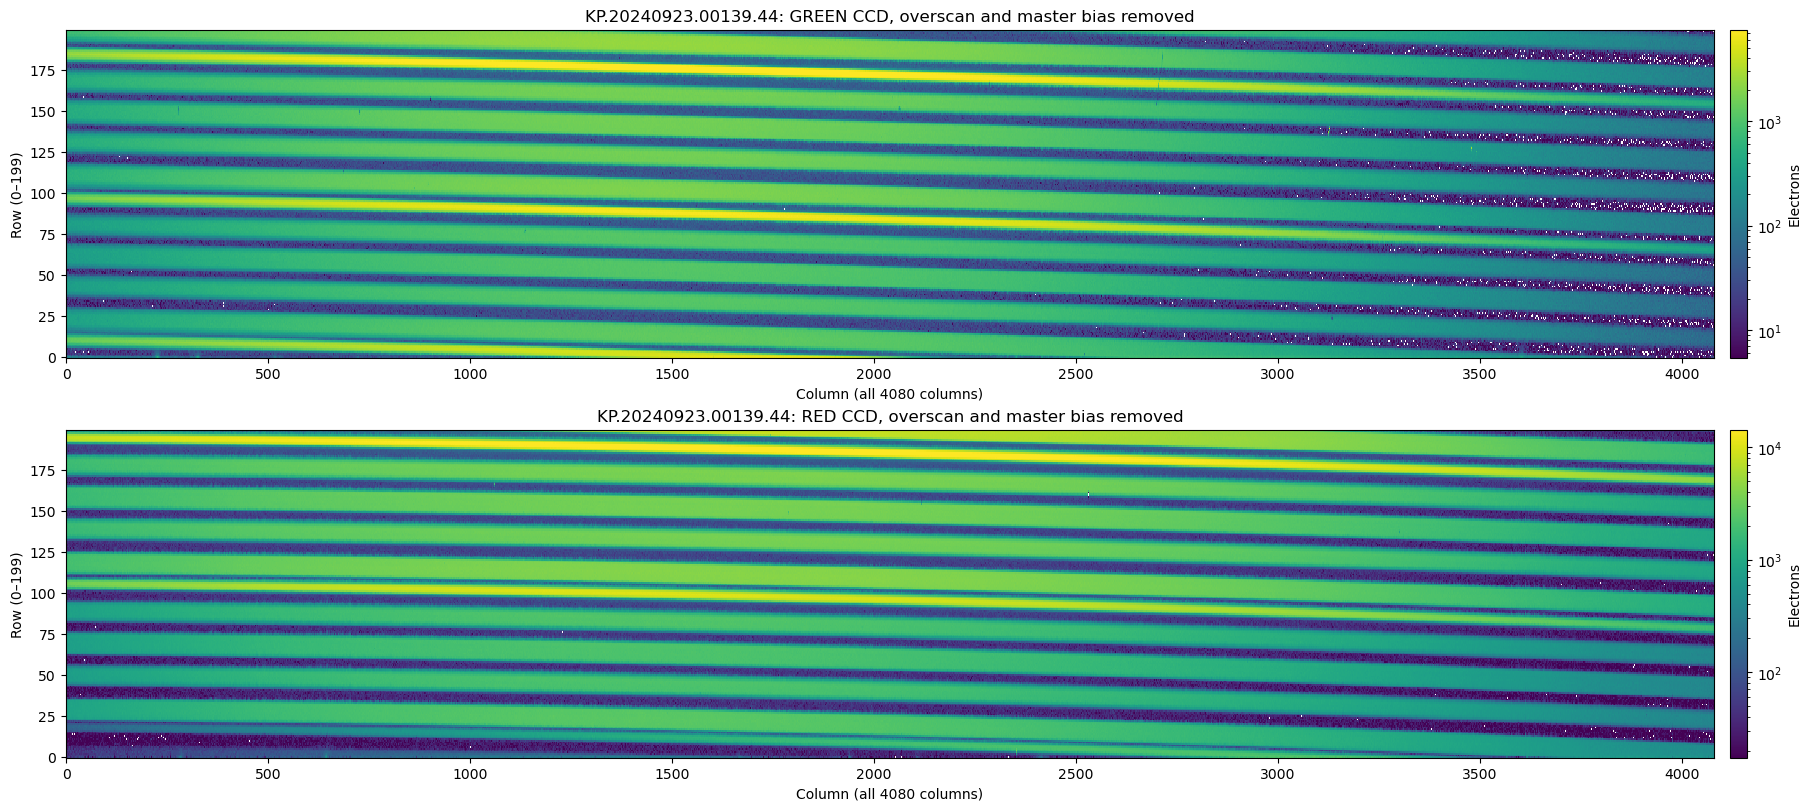

In [4]:
# First 500 rows and every detector column, after overscan and bias removal.
fig, axes = plt.subplots(2, 1, figsize=(18, 8), constrained_layout=True)

def positive_log_norm(data, lower_percentile=1.0, upper_percentile=99.5):
    """Log normalization from finite positive pixels only."""
    positive = np.asarray(data)[np.isfinite(data) & (np.asarray(data) > 0)]
    if positive.size == 0:
        raise ValueError("log-scaled image has no finite positive pixels")
    vmin, vmax = np.nanpercentile(positive, (lower_percentile, upper_percentile))
    return LogNorm(vmin=vmin, vmax=vmax)

for ax, chip in zip(axes, ("GREEN", "RED"), strict=True):
    image = np.asarray(l1.data[f"{chip}_CCD"])[:200, :]
    plotted = ax.imshow(
        np.ma.masked_less_equal(image, 0),
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
        norm=positive_log_norm(image),
    )
    ax.set_title(f"{obs_id}: {chip} CCD, overscan and master bias removed")
    ax.set_xlabel(f"Column (all {image.shape[1]} columns)")
    ax.set_ylabel("Row (0–199)")
    fig.colorbar(plotted, ax=ax, label="Electrons", pad=0.01)

plt.show()

## Robust cubic traces for one GREEN order

Set `selected_order` in the next cell to inspect another physical order. A coarse reference position identifies each fiber, but the plotted trace is refit from centers measured directly from this flat. Each center comes from a median-combined column strip and a background-subtracted local flux centroid. A cubic is then fit with iterative MAD-based rejection of deviant samples:

$$y_f(x) = c_{0,f} + c_{1,f}x + c_{2,f}x^2 + c_{3,f}x^3.$$

,Fiber,c0,c1,c2,c3,kept,RMS_pix
0,SKY,110.622508,-0.005955,-3.729878e-07,-1.472098e-11,65,0.697357
1,SCI1,130.895371,-0.003987,-1.269261e-06,1.098139e-10,65,0.372934
2,SCI2,150.453944,-0.004547,-9.365078e-07,5.665791e-11,65,1.078540
3,SCI3,168.720468,-0.005270,-2.835296e-07,-6.784548e-11,65,0.661502
4,CAL,184.202595,-0.004717,-7.913001e-07,3.307861e-11,65,0.058223


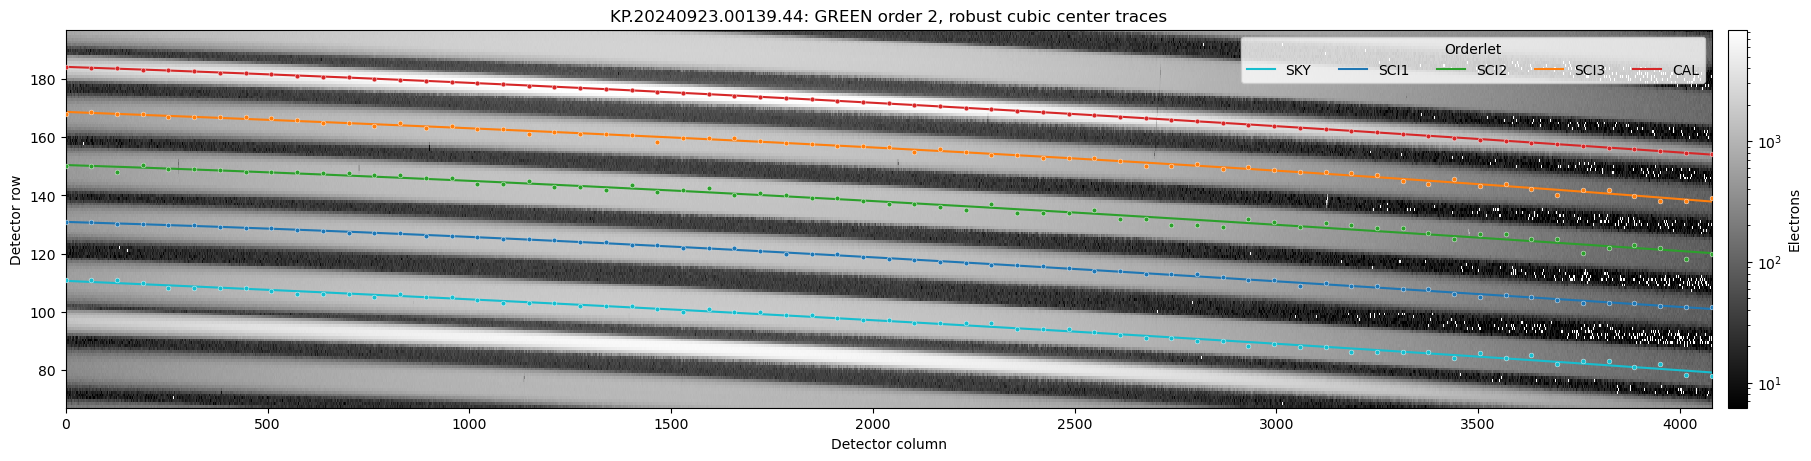

In [5]:
from scipy.ndimage import gaussian_filter1d

selected_order = 2  # Change this value to inspect a different GREEN order.
fibers = ["SKY", "SCI1", "SCI2", "SCI3", "CAL"]
green = np.asarray(l1.data["GREEN_CCD"], dtype=float)
nrow, ncol = green.shape
sample_x = np.unique(np.linspace(0, ncol - 1, 65, dtype=int))

# The existing table supplies only a coarse seed for identifying the requested
# order/fiber. All centers and final coefficients below come from this flat.
reference = pd.read_csv(REPO_ROOT / "reference/order_trace_green.csv", index_col=0)
selected = reference[reference["Order"] == selected_order].set_index("Fiber")
missing = set(fibers).difference(selected.index)
if missing:
    raise ValueError(f"GREEN order {selected_order} is missing fibers: {sorted(missing)}")

def local_center(image, column, guess, row_half_window=7, col_half_window=3):
    """Robust subpixel center from a median column strip near ``guess``."""
    c0 = max(0, int(column) - col_half_window)
    c1 = min(image.shape[1], int(column) + col_half_window + 1)
    r0 = max(0, int(np.floor(guess)) - row_half_window)
    r1 = min(image.shape[0], int(np.ceil(guess)) + row_half_window + 1)
    rows = np.arange(r0, r1, dtype=float)
    profile = np.nanmedian(image[r0:r1, c0:c1], axis=1)
    background = np.nanpercentile(profile, 20.0)
    signal = np.clip(profile - background, 0.0, None)
    smoothed = gaussian_filter1d(np.nan_to_num(signal), sigma=1.0)
    peak = int(np.argmax(smoothed))
    lo, hi = max(0, peak - 3), min(signal.size, peak + 4)
    weights = signal[lo:hi]
    if not np.isfinite(weights).all() or weights.sum() <= 0:
        return np.nan
    # Winsorization prevents one hot pixel from pulling the centroid.
    weights = np.minimum(weights, np.nanpercentile(weights, 90.0))
    return np.average(rows[lo:hi], weights=weights)

def trace_centers(image, seed_y, columns):
    """Follow one orderlet outward from the detector center."""
    centers = np.full(columns.size, np.nan)
    anchor = int(np.argmin(np.abs(columns - image.shape[1] // 2)))
    centers[anchor] = local_center(image, columns[anchor], seed_y)
    for indices in (range(anchor + 1, columns.size), range(anchor - 1, -1, -1)):
        previous = anchor
        for i in indices:
            centers[i] = local_center(image, columns[i], centers[previous])
            if np.isfinite(centers[i]):
                previous = i
    return centers

def robust_cubic_fit(x, y, sigma=4.0, max_iterations=8):
    """Cubic fit with iterative median/MAD residual rejection."""
    keep = np.isfinite(x) & np.isfinite(y)
    if keep.sum() < 4:
        raise ValueError("fewer than four finite trace centers")
    for _ in range(max_iterations):
        coeff = np.polynomial.polynomial.polyfit(x[keep], y[keep], 3)
        residual = y - np.polynomial.polynomial.polyval(x, coeff)
        center = np.nanmedian(residual[keep])
        scale = 1.4826 * np.nanmedian(np.abs(residual[keep] - center))
        limit = max(0.25, sigma * scale)
        updated = np.isfinite(y) & (np.abs(residual - center) <= limit)
        if np.array_equal(updated, keep):
            break
        keep = updated
    coeff = np.polynomial.polynomial.polyfit(x[keep], y[keep], 3)
    return coeff, keep

fits = {}
summary = []
anchor_x = sample_x[np.argmin(np.abs(sample_x - ncol // 2))]
for fiber in fibers:
    seed_row = selected.loc[fiber]
    seed_coeff = [seed_row[f"Coeff{i}"] for i in range(4)]
    seed_y = np.polynomial.polynomial.polyval(anchor_x, seed_coeff)
    measured_y = trace_centers(green, seed_y, sample_x)
    coeff, keep = robust_cubic_fit(sample_x.astype(float), measured_y)
    fits[fiber] = {"coeff": coeff, "measured_y": measured_y, "keep": keep}
    residual = measured_y[keep] - np.polynomial.polynomial.polyval(sample_x[keep], coeff)
    summary.append(
        {"Fiber": fiber, **{f"c{i}": coeff[i] for i in range(4)},
         "kept": int(keep.sum()), "RMS_pix": np.sqrt(np.mean(residual**2))}
    )

fit_summary = pd.DataFrame(summary)
display(fit_summary)

plot_x = np.arange(ncol, dtype=float)
curves = {fiber: np.polynomial.polynomial.polyval(plot_x, fits[fiber]["coeff"]) for fiber in fibers}
row_min = max(0, int(np.floor(min(curve.min() for curve in curves.values()) - 12)))
row_max = min(nrow - 1, int(np.ceil(max(curve.max() for curve in curves.values()) + 12)))
order_image = green[row_min : row_max + 1, :]

fig, ax = plt.subplots(figsize=(18, 4.5), constrained_layout=True)
shown = ax.imshow(np.ma.masked_less_equal(order_image, 0),
                  extent=(0, ncol - 1, row_min, row_max), origin="lower",
                  aspect="auto", interpolation="nearest", cmap="gray",
                  norm=positive_log_norm(order_image))
colors = {"SKY": "tab:cyan", "SCI1": "tab:blue", "SCI2": "tab:green",
          "SCI3": "tab:orange", "CAL": "tab:red"}
for fiber in fibers:
    result = fits[fiber]
    ax.plot(plot_x, curves[fiber], color=colors[fiber], linewidth=1.5, label=fiber)
    ax.scatter(sample_x[result["keep"]], result["measured_y"][result["keep"]],
               color=colors[fiber], edgecolor="white", linewidth=0.3, s=12, zorder=3)
    rejected = ~result["keep"]
    ax.scatter(sample_x[rejected], result["measured_y"][rejected], marker="x",
               color=colors[fiber], s=20, zorder=5)
ax.set_xlim(0, ncol - 1)
ax.set_ylim(row_min, row_max)
ax.set_title(f"{obs_id}: GREEN order {selected_order}, robust cubic center traces")
ax.set_xlabel("Detector column")
ax.set_ylabel("Detector row")
ax.legend(title="Orderlet", ncol=5, loc="upper right")
fig.colorbar(shown, ax=ax, label="Electrons", pad=0.01)
plt.show()

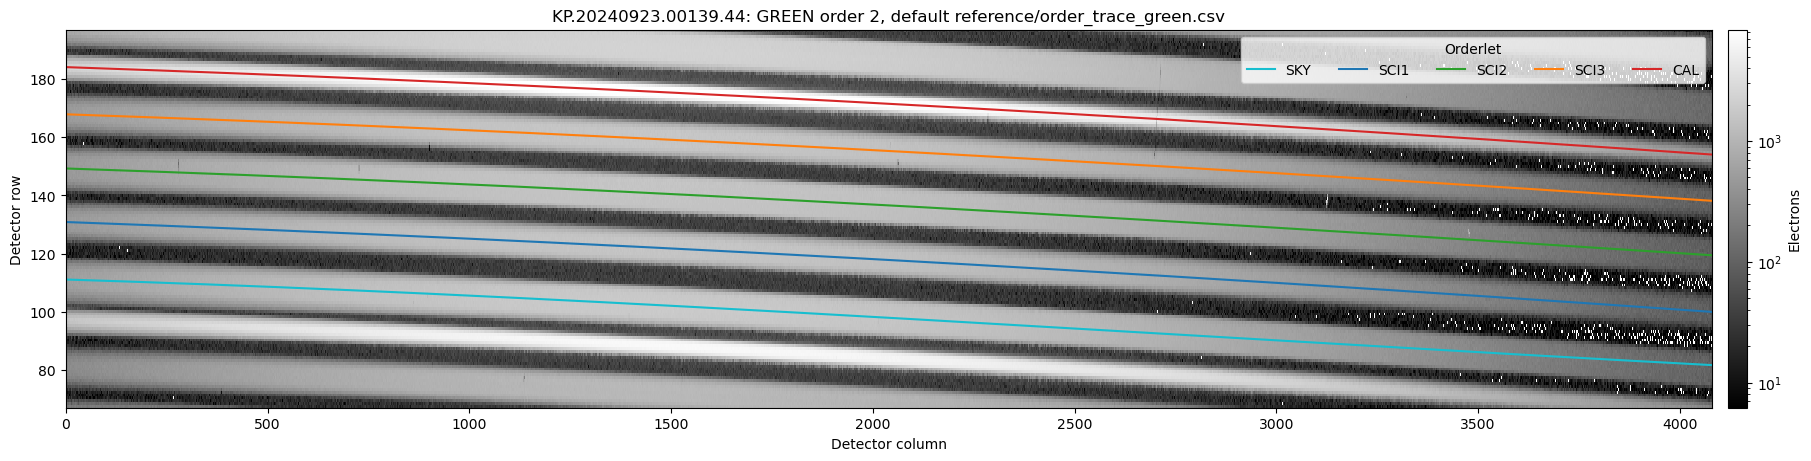

In [6]:
# Direct comparison: the same cutout with the untouched default GREEN trace.
default_curves = {}
for fiber in fibers:
    default_row = selected.loc[fiber]
    default_coeff = [default_row[f"Coeff{i}"] for i in range(4)]
    default_curves[fiber] = np.polynomial.polynomial.polyval(plot_x, default_coeff)

fig, ax = plt.subplots(figsize=(18, 4.5), constrained_layout=True)
shown = ax.imshow(
    np.ma.masked_less_equal(order_image, 0),
    extent=(0, ncol - 1, row_min, row_max),
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap="gray",
    norm=positive_log_norm(order_image),
)
for fiber in fibers:
    ax.plot(
        plot_x, default_curves[fiber], color=colors[fiber], linewidth=1.5, label=fiber
    )
ax.set_xlim(0, ncol - 1)
ax.set_ylim(row_min, row_max)
ax.set_title(
    f"{obs_id}: GREEN order {selected_order}, default reference/order_trace_green.csv"
)
ax.set_xlabel("Detector column")
ax.set_ylabel("Detector row")
ax.legend(title="Orderlet", ncol=5, loc="upper right")
fig.colorbar(shown, ax=ax, label="Electrons", pad=0.01)
plt.show()

## Write a pipeline-compatible GREEN trace table

The CSV uses the same rows, columns, ordering, and serialized index as `reference/order_trace_green.csv`. At this stage only `selected_order` has been measured from the new flat, so its five cubic coefficient rows are replaced while the remaining orders and the aperture-width metadata (`BottomEdge`, `TopEdge`, `X1`, and `X2`) retain their reference values. As more orders are fitted, their rows can be replaced in the same table.

In [7]:
import csv

output_dir = data_root / "order_trace_issue_1398"
output_dir.mkdir(parents=True, exist_ok=True)
trace_output_path = output_dir / "order_trace_green.csv"

# Begin with the complete pipeline-compatible schema, then replace the five
# coefficient rows actually measured for the selected order in this notebook.
trace_table = reference.copy()
coefficient_columns = [f"Coeff{i}" for i in range(4)]
updated_indices = []
for fiber in fibers:
    row_mask = (trace_table["Order"] == selected_order) & (trace_table["Fiber"] == fiber)
    if row_mask.sum() != 1:
        raise ValueError(
            f"expected one GREEN order {selected_order} / {fiber} row; found {row_mask.sum()}"
        )
    trace_table.loc[row_mask, coefficient_columns] = fits[fiber]["coeff"]
    updated_indices.append(int(trace_table.index[row_mask][0]))

# Preserve every untouched CSV field verbatim and replace only the fitted
# coefficient strings. The first column remains the serialized DataFrame index
# expected by SpectralExtraction's pd.read_csv(..., index_col=0) reader.
trace_table = trace_table[reference.columns]
reference_path = REPO_ROOT / "reference/order_trace_green.csv"
with reference_path.open(newline="") as stream:
    csv_rows = list(csv.reader(stream))
csv_header = csv_rows[0]
for index in updated_indices:
    for column in coefficient_columns:
        csv_rows[index + 1][csv_header.index(column)] = repr(float(trace_table.loc[index, column]))
with trace_output_path.open("w", newline="") as stream:
    csv.writer(stream, lineterminator="\n").writerows(csv_rows)

written = pd.read_csv(trace_output_path, index_col=0)
if written.columns.tolist() != reference.columns.tolist():
    raise RuntimeError("written trace CSV does not match the reference schema")
if len(written) != len(reference):
    raise RuntimeError("written trace CSV does not contain the complete GREEN table")
with trace_output_path.open(newline="") as stream:
    written_rows = list(csv.reader(stream))
for index in set(reference.index).difference(updated_indices):
    if written_rows[index + 1] != csv_rows[index + 1]:
        raise RuntimeError(f"untouched CSV row {index} changed during serialization")

print(f"Wrote {len(written)} trace rows to {trace_output_path}")
display(written[written["Order"] == selected_order])
trace_output_path

Wrote 175 trace rows to /Users/howardisaacson/data/kpf/order_trace_issue_1398/order_trace_green.csv


,Coeff0,Coeff1,Coeff2,Coeff3,BottomEdge,TopEdge,X1,X2,Fiber,Order
5,110.622508,-0.005955,-3.729878e-07,-1.472098e-11,9.3545,9.3545,0,3794,SKY,2
6,130.895371,-0.003987,-1.269261e-06,1.098139e-10,9.3201,9.0291,0,3873,SCI1,2
7,150.453944,-0.004547,-9.365078e-07,5.665791e-11,8.7487,9.6587,0,3816,SCI2,2
8,168.720468,-0.005270,-2.835296e-07,-6.784548e-11,8.0397,8.9974,0,3779,SCI3,2
9,184.202595,-0.004717,-7.913001e-07,3.307861e-11,6.1852,6.1852,0,4079,CAL,2


PosixPath('/Users/howardisaacson/data/kpf/order_trace_issue_1398/order_trace_green.csv')

In [8]:
# Run the production module on the same raw wideflat used above.
from kpfpipe.modules.order_trace import OrderTrace

module_output_dir = data_root / "order_trace_issue_1398" / "module"
order_tracer = OrderTrace(
    str(l0_path),
    config={"KPF_MASTERS_OUTPUT": str(data_root)},
)
order_trace_tables = order_tracer.perform(
    output_dir=module_output_dir,
    overwrite=True,
)
order_tracer.info()

{
    chip: {
        "rows": len(table),
        "output": str(module_output_dir / f"order_trace_{chip.lower()}.csv"),
    }
    for chip, table in order_trace_tables.items()
}




OrderTrace
  wideflat: /Users/howardisaacson/data/kpf/L0/20240923/KP.20240923.00139.44.fits
  bias:     /Users/howardisaacson/data/kpf/masters/20240923/KP.20240923.03637.97_master_bias_L1.fits
  INSTERA:  2.0

  chip      traces   seed shift   median RMS [pix]  output
  ------------------------------------------------------------------------------------------
  GREEN        175        0.000             0.3911  /Users/howardisaacson/data/kpf/order_trace_issue_1398/module/order_trace_green.csv
  RED          159        0.000             0.2698  /Users/howardisaacson/data/kpf/order_trace_issue_1398/module/order_trace_red.csv




{'GREEN': {'rows': 175,
  'output': '/Users/howardisaacson/data/kpf/order_trace_issue_1398/module/order_trace_green.csv'},
 'RED': {'rows': 159,
  'output': '/Users/howardisaacson/data/kpf/order_trace_issue_1398/module/order_trace_red.csv'}}

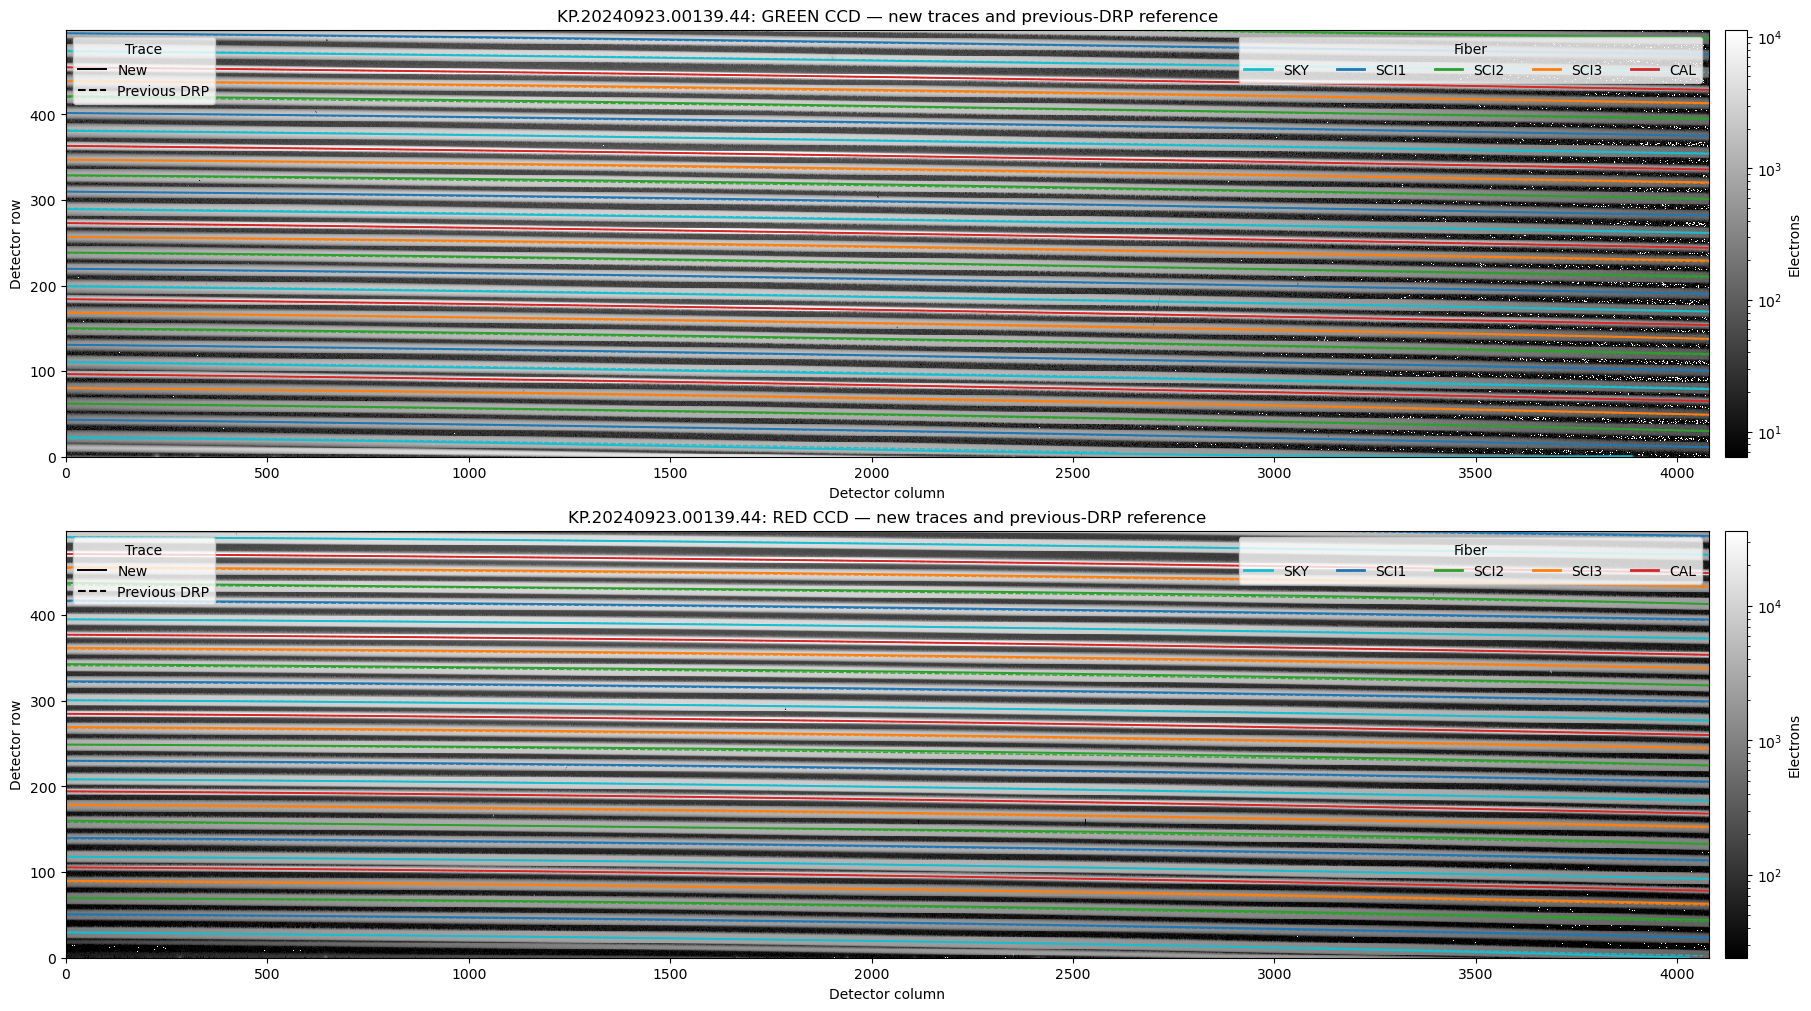

In [9]:
# Compare the new traces with this night's previous-DRP trace products.
from matplotlib.lines import Line2D

legacy_trace_paths = {
    "GREEN": Path("/Users/howardisaacson/data/kpf/masters/20240923/kpf_20240923_master_flat_GREEN_CCD.csv"),
    "RED": Path("/Users/howardisaacson/data/kpf/masters/20240923/kpf_20240923_master_flat_RED_CCD.csv"),
}

def load_legacy_trace(path, chip, ncol):
    """Load, label, and orient a previous-DRP trace table for vNext."""
    table = pd.read_csv(path, index_col=0)
    table = table[(table["BottomEdge"] > 0) & (table["TopEdge"] > 0)].reset_index(drop=True)
    norder = order_tracer.norder[chip]
    expected_rows = norder * len(fibers)
    if len(table) != expected_rows:
        raise ValueError(f"{path} has {len(table)} usable rows; expected {expected_rows}")

    table["Fiber"] = np.tile(fibers, norder)
    table["Order"] = np.repeat(np.arange(1, norder + 1), len(fibers))

    # The previous DRP used the opposite dispersion orientation. Compose
    # P_old(x) with x_old = (ncol - 1) - x_vnext.
    detector_end = float(ncol - 1)
    coeff_columns = [f"Coeff{i}" for i in range(4)]
    coeff = table[coeff_columns].to_numpy(dtype=float)
    table[coeff_columns] = np.column_stack(
        (
            coeff[:, 0] + coeff[:, 1] * detector_end + coeff[:, 2] * detector_end**2 + coeff[:, 3] * detector_end**3,
            -coeff[:, 1] - 2 * coeff[:, 2] * detector_end - 3 * coeff[:, 3] * detector_end**2,
            coeff[:, 2] + 3 * coeff[:, 3] * detector_end,
            -coeff[:, 3],
        )
    )
    old_x1 = table["X1"].copy()
    old_x2 = table["X2"].copy()
    table["X1"] = ncol - 1 - old_x2
    table["X2"] = ncol - 1 - old_x1
    return table

legacy_trace_tables = {
    chip: load_legacy_trace(
        path, chip, np.asarray(l1.data[f"{chip}_CCD"]).shape[1]
    )
    for chip, path in legacy_trace_paths.items()
}

trace_colors = {
    "SKY": "tab:cyan",
    "SCI1": "tab:blue",
    "SCI2": "tab:green",
    "SCI3": "tab:orange",
    "CAL": "tab:red",
}
plot_rows = 500
fig, axes = plt.subplots(2, 1, figsize=(18, 10), constrained_layout=True)

for ax, chip in zip(axes, ("GREEN", "RED"), strict=True):
    image = np.asarray(l1.data[f"{chip}_CCD"])[:plot_rows, :]
    ncol = image.shape[1]
    plot_x = np.arange(ncol, dtype=float)
    shown = ax.imshow(
        np.ma.masked_less_equal(image, 0),
        extent=(0, ncol - 1, 0, plot_rows - 1),
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="gray",
        norm=positive_log_norm(image),
    )
    for trace in order_trace_tables[chip].itertuples(index=False):
        coeffs = [getattr(trace, f"Coeff{i}") for i in range(4)]
        trace_y = np.polynomial.polynomial.polyval(plot_x, coeffs)
        visible = (trace_y >= 0) & (trace_y < plot_rows) & (plot_x >= trace.X1) & (plot_x <= trace.X2)
        if not visible.any():
            continue
        ax.plot(
            plot_x[visible],
            trace_y[visible],
            color=trace_colors[trace.Fiber],
            linewidth=1.4,
        )
    for trace in legacy_trace_tables[chip].itertuples(index=False):
        coeffs = [getattr(trace, f"Coeff{i}") for i in range(4)]
        trace_y = np.polynomial.polynomial.polyval(plot_x, coeffs)
        visible = (trace_y >= 0) & (trace_y < plot_rows) & (plot_x >= trace.X1) & (plot_x <= trace.X2)
        if not visible.any():
            continue
        ax.plot(
            plot_x[visible],
            trace_y[visible],
            color=trace_colors[trace.Fiber],
            linestyle="--",
            linewidth=1.0,
            alpha=0.9,
        )
    ax.set_xlim(0, ncol - 1)
    ax.set_ylim(0, plot_rows - 1)
    ax.set_title(f"{obs_id}: {chip} CCD — new traces and previous-DRP reference")
    ax.set_xlabel("Detector column")
    ax.set_ylabel("Detector row")
    fiber_handles = [
        Line2D([0], [0], color=trace_colors[fiber], linewidth=2, label=fiber)
        for fiber in fibers
    ]
    method_handles = [
        Line2D([0], [0], color="black", linewidth=1.4, label="New"),
        Line2D([0], [0], color="black", linestyle="--", label="Previous DRP"),
    ]
    fiber_legend = ax.legend(handles=fiber_handles, title="Fiber", ncol=5, loc="upper right")
    ax.add_artist(fiber_legend)
    ax.legend(handles=method_handles, title="Trace", loc="upper left")
    fig.colorbar(shown, ax=ax, label="Electrons", pad=0.01)

plt.show()


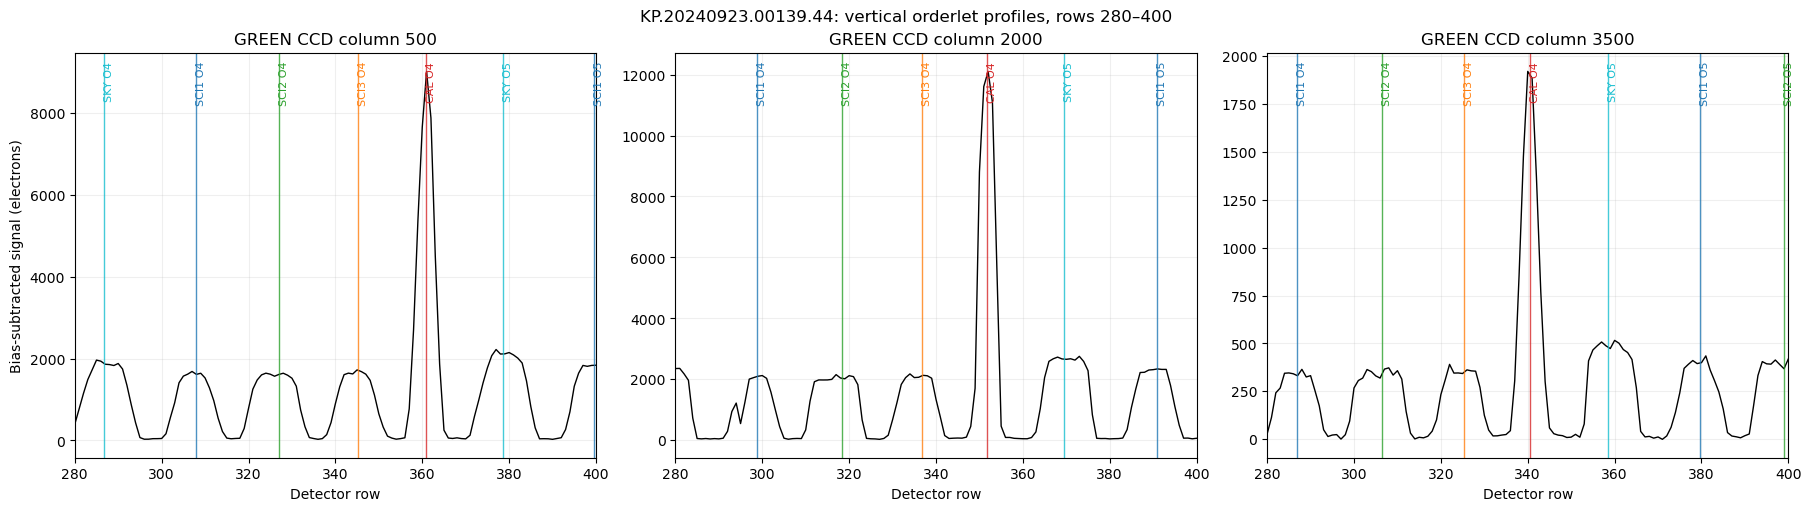

In [10]:
# Vertical GREEN CCD profiles at three detector columns.
cut_columns = (500, 2000, 3500)
row_start, row_stop = 280, 400
green_image = np.asarray(l1.data["GREEN_CCD"])
cut_rows = np.arange(row_start, row_stop + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, constrained_layout=True)

for ax, column in zip(axes, cut_columns, strict=True):
    profile = green_image[cut_rows, column]
    ax.plot(cut_rows, profile, color="black", linewidth=1.0)

    for trace in order_trace_tables["GREEN"].itertuples(index=False):
        if not trace.X1 <= column <= trace.X2:
            continue
        coeffs = [getattr(trace, f"Coeff{i}") for i in range(4)]
        center = np.polynomial.polynomial.polyval(column, coeffs)
        if not row_start <= center <= row_stop:
            continue
        ax.axvline(
            center, color=trace_colors[trace.Fiber], linewidth=1.0, alpha=0.8
        )
        ax.text(
            center,
            0.98,
            f"{trace.Fiber} O{trace.Order}",
            color=trace_colors[trace.Fiber],
            rotation=90,
            rotation_mode="anchor",
            ha="right",
            va="top",
            fontsize=8,
            transform=ax.get_xaxis_transform(),
        )

    ax.set_xlim(row_start, row_stop)
    ax.set_title(f"GREEN CCD column {column}")
    ax.set_xlabel("Detector row")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Bias-subtracted signal (electrons)")
fig.suptitle(f"{obs_id}: vertical orderlet profiles, rows {row_start}–{row_stop}")
plt.show()


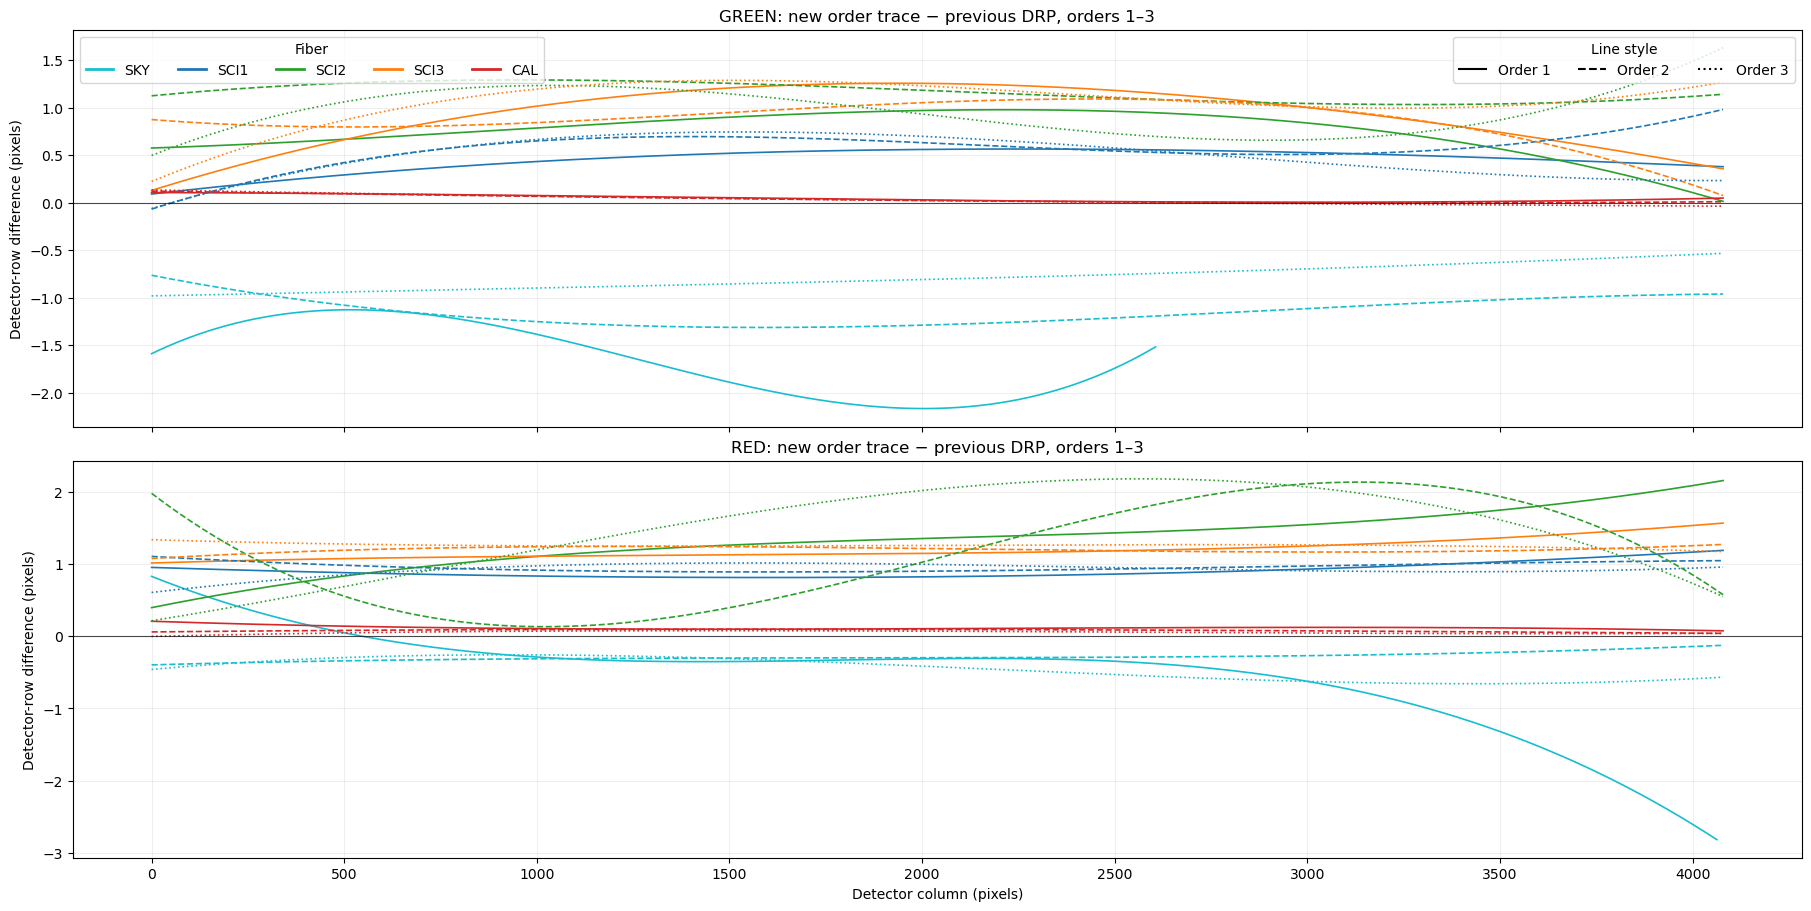

In [11]:
# Difference between the new and previous-DRP traces for orders 1–3.
order_styles = {1: "-", 2: "--", 3: ":"}
fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True, constrained_layout=True)

for ax, chip in zip(axes, ("GREEN", "RED"), strict=True):
    legacy_table = legacy_trace_tables[chip].set_index(["Fiber", "Order"]).sort_index()
    new_table = order_trace_tables[chip].set_index(["Fiber", "Order"]).sort_index()

    for order in (1, 2, 3):
        for fiber in fibers:
            key = (fiber, order)
            if key not in legacy_table.index or key not in new_table.index:
                continue
            legacy_trace = legacy_table.loc[key]
            new_trace = new_table.loc[key]
            x1 = int(max(legacy_trace.X1, new_trace.X1))
            x2 = int(min(legacy_trace.X2, new_trace.X2))
            if x2 < x1:
                continue
            pixel = np.arange(x1, x2 + 1, dtype=float)
            legacy_coeffs = [legacy_trace[f"Coeff{i}"] for i in range(4)]
            new_coeffs = [new_trace[f"Coeff{i}"] for i in range(4)]
            difference = (
                np.polynomial.polynomial.polyval(pixel, new_coeffs)
                - np.polynomial.polynomial.polyval(pixel, legacy_coeffs)
            )
            ax.plot(
                pixel,
                difference,
                color=trace_colors[fiber],
                linestyle=order_styles[order],
                linewidth=1.2,
            )

    ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)
    ax.set_title(f"{chip}: new order trace − previous DRP, orders 1–3")
    ax.set_ylabel("Detector-row difference (pixels)")
    ax.grid(alpha=0.2)

fiber_handles = [
    Line2D([0], [0], color=trace_colors[fiber], linewidth=2, label=fiber)
    for fiber in fibers
]
order_handles = [
    Line2D([0], [0], color="black", linestyle=style, label=f"Order {order}")
    for order, style in order_styles.items()
]
fiber_legend = axes[0].legend(
    handles=fiber_handles, title="Fiber", ncol=5, loc="upper left"
)
axes[0].add_artist(fiber_legend)
axes[0].legend(handles=order_handles, title="Line style", ncol=3, loc="upper right")
axes[-1].set_xlabel("Detector column (pixels)")
plt.show()
